<a href="https://colab.research.google.com/github/SimmyKumari12/VOIS-Major-Project/blob/main/VOISMajorProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Statistical analysis
from scipy import stats

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("/content/seasonal_agriculture_performance_dataset (2).csv")

df.head()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,7.14,32.8,75.8,61.3,91.0,Drip,242.7,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,5.20,32.0,82.1,35.4,121.8,Flood,271.4,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,5.82,8.1,118.5,51.5,117.9,Drip,162.6,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,5.98,23.7,138.6,55.6,115.5,Rainfed,182.2,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,6.90,29.3,124.1,69.0,121.4,Flood,244.9,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [4]:
df.shape

(4000, 28)

In [5]:
df.columns

Index(['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Farm_Area_Hectares',
       'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct',
       'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha',
       'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Irrigation_Method',
       'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score',
       'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne',
       'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3',
       'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

In [8]:
df.describe()

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
count,4000.000000,3952.000000,4000.00000,4000.000000,4000.000000,4000.000000,3960.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,3968.000000,4000.000000,4000.000000,4.000000e+03,4.000000e+03,4.000000e+03,4000.000000,4000.000000,4000.000000
mean,7.888265,601.152657,26.81890,63.210500,7.323050,6.701010,26.508232,120.250825,57.781850,104.760050,186.036000,5.070935,0.826138,5.270595,43.246210,44714.166250,5.263036e+05,6.378600e+05,1.115565e+05,6045.570250,5.385214,46.365875
std,4.223764,288.925025,3.81818,11.960834,1.121186,0.641461,6.712484,31.216452,17.015074,27.742681,60.260583,1.978879,0.101747,13.361398,126.880521,30266.161922,2.944191e+05,6.369747e+05,5.450819e+05,5572.944306,8.838101,12.424417
min,0.500000,80.000000,16.20000,25.000000,3.500000,5.200000,8.000000,40.000000,15.000000,30.000000,40.000000,0.500000,0.650000,0.300000,0.150000,2594.000000,2.682600e+04,6.107000e+03,-1.019223e+06,128.000000,0.135000,5.000000
25%,4.260000,370.200000,23.90000,54.775000,6.600000,6.260000,21.700000,98.500000,46.200000,86.200000,143.975000,3.690000,0.740000,1.050000,5.020000,21429.250000,2.745775e+05,2.075172e+05,-1.487318e+05,2268.750000,1.661000,37.300000
50%,7.895000,582.000000,26.90000,63.000000,7.300000,6.690000,26.400000,120.100000,57.500000,105.100000,186.250000,5.120000,0.830000,1.740000,11.770000,25913.000000,5.190825e+05,4.568305e+05,3.673000e+03,4435.000000,2.937500,46.400000
75%,11.650000,834.950000,29.60000,71.900000,8.100000,7.140000,31.300000,141.225000,69.400000,123.600000,227.200000,6.400000,0.910000,2.840000,24.355000,68279.000000,7.619965e+05,8.368748e+05,2.161878e+05,7829.750000,5.150250,54.900000
max,15.000000,1395.200000,39.70000,95.000000,11.000000,8.400000,47.000000,220.000000,120.000000,200.000000,400.000000,12.080000,1.000000,101.440000,1424.400000,131240.000000,1.349990e+06,5.080900e+06,4.345421e+06,40902.000000,79.800000,88.900000


In [9]:
df.isnull().sum()

,0
Farm_ID,0
State,0
District,0
Crop,0
Season,0
Farm_Area_Hectares,0
Rainfall_mm,48
Avg_Temperature_C,0
Humidity_pct,0
Sunlight_Hours_Day,0


In [11]:
missing_values = (df.isnull().sum())/len(df) * 100
missing_values.sort_values(ascending = False)

,0
Rainfall_mm,1.2
Soil_Moisture_pct,1.0
Yield_Tonnes_Ha,0.8
Farm_ID,0.0
Crop,0.0
District,0.0
Farm_Area_Hectares,0.0
Season,0.0
Avg_Temperature_C,0.0
Humidity_pct,0.0


In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
categorical_columns = df.select_dtypes(include='object').columns

for col in categorical_columns:
    print(f"\n{col}")
    print(df[col].unique())


Farm_ID
['SF10001' 'SF10002' 'SF10003' ... 'SF13998' 'SF13999' 'SF14000']

State
['Andhra Pradesh' 'Maharashtra' 'Telangana' 'Karnataka' 'Gujarat'
 'Tamil Nadu' 'Punjab' 'Madhya Pradesh']

District
['Rajkot' 'Nalgonda' 'Warangal' 'Indore' 'Ludhiana' 'Raichur' 'Guntur'
 'Krishna' 'Nashik' 'Erode']

Crop
['Wheat' 'Maize' 'Pulses' 'Rice' 'Cotton' 'Chilli' 'Groundnut' 'Sugarcane']

Season
['Kharif' 'Rabi' 'Zaid']

Irrigation_Method
['Drip' 'Flood' 'Rainfed' 'Sprinkler']


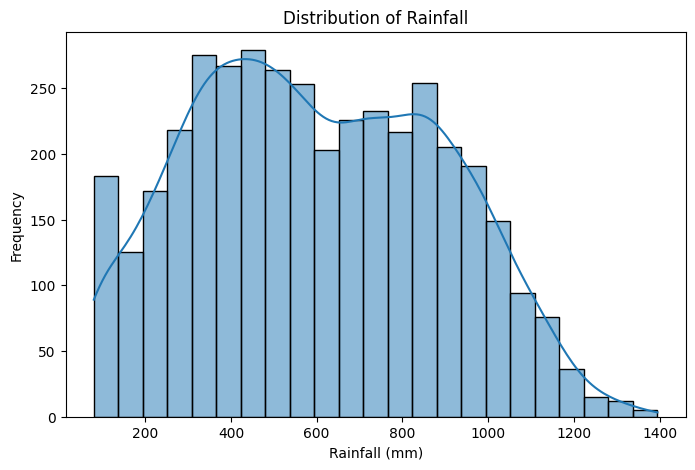

In [14]:
plt.figure(figsize=(8,5))

sns.histplot(df['Rainfall_mm'], kde=True)

plt.title('Distribution of Rainfall')
plt.xlabel('Rainfall (mm)')
plt.ylabel('Frequency')

plt.show()

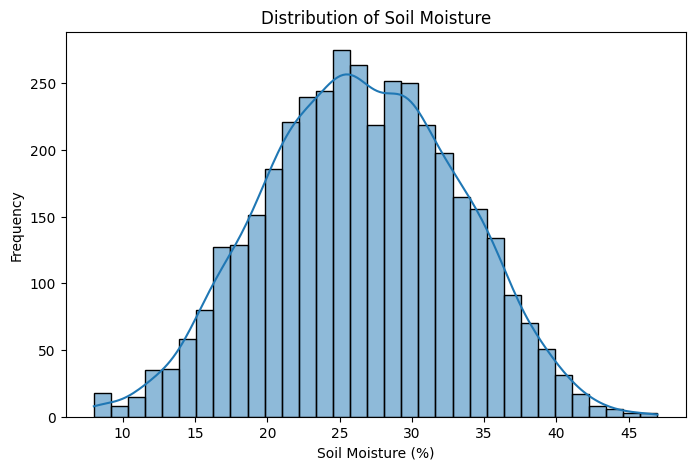

In [16]:
plt.figure(figsize=(8,5))

sns.histplot(df['Soil_Moisture_pct'], kde=True)

plt.title('Distribution of Soil Moisture')
plt.xlabel('Soil Moisture (%)')
plt.ylabel('Frequency')

plt.show()

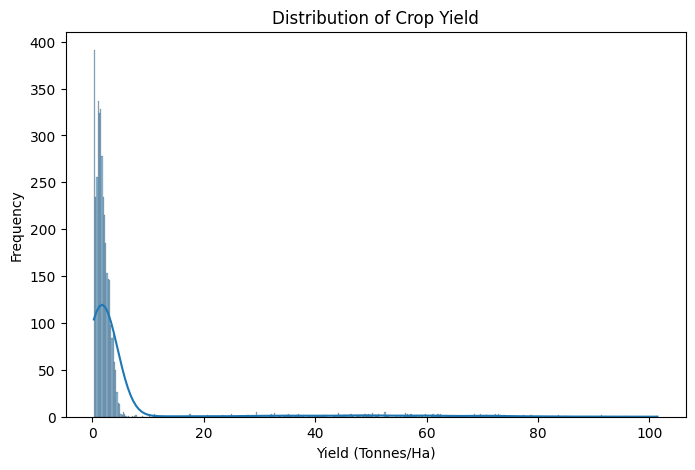

In [18]:
plt.figure(figsize=(8,5))

sns.histplot(df['Yield_Tonnes_Ha'], kde=True)

plt.title('Distribution of Crop Yield')
plt.xlabel('Yield (Tonnes/Ha)')
plt.ylabel('Frequency')

plt.show()

In [21]:
df['Rainfall_mm'] = df['Rainfall_mm'].fillna(df['Rainfall_mm'].median())

df['Soil_Moisture_pct'] = df['Soil_Moisture_pct'].fillna(
    df['Soil_Moisture_pct'].median()
)

df['Yield_Tonnes_Ha'] = df['Yield_Tonnes_Ha'].fillna(
    df['Yield_Tonnes_Ha'].median()
)

In [23]:
df.isnull().sum().sum()

np.int64(0)

In [24]:
df['Soil_pH'].describe()

,Soil_pH
count,4000.000000
mean,6.701010
std,0.641461
min,5.200000
25%,6.260000
50%,6.690000
75%,7.140000
max,8.400000


In [25]:
df['Humidity_pct'].describe()

,Humidity_pct
count,4000.000000
mean,63.210500
std,11.960834
min,25.000000
25%,54.775000
50%,63.000000
75%,71.900000
max,95.000000


In [26]:
df['Seed_Quality_Score'].describe()

,Seed_Quality_Score
count,4000.000000
mean,0.826138
std,0.101747
min,0.650000
25%,0.740000
50%,0.830000
75%,0.910000
max,1.000000


In [27]:
df['Yield_Tonnes_Ha'].describe()

,Yield_Tonnes_Ha
count,4000.000000
mean,5.242350
std,13.311549
min,0.300000
25%,1.050000
50%,1.740000
75%,2.830000
max,101.440000


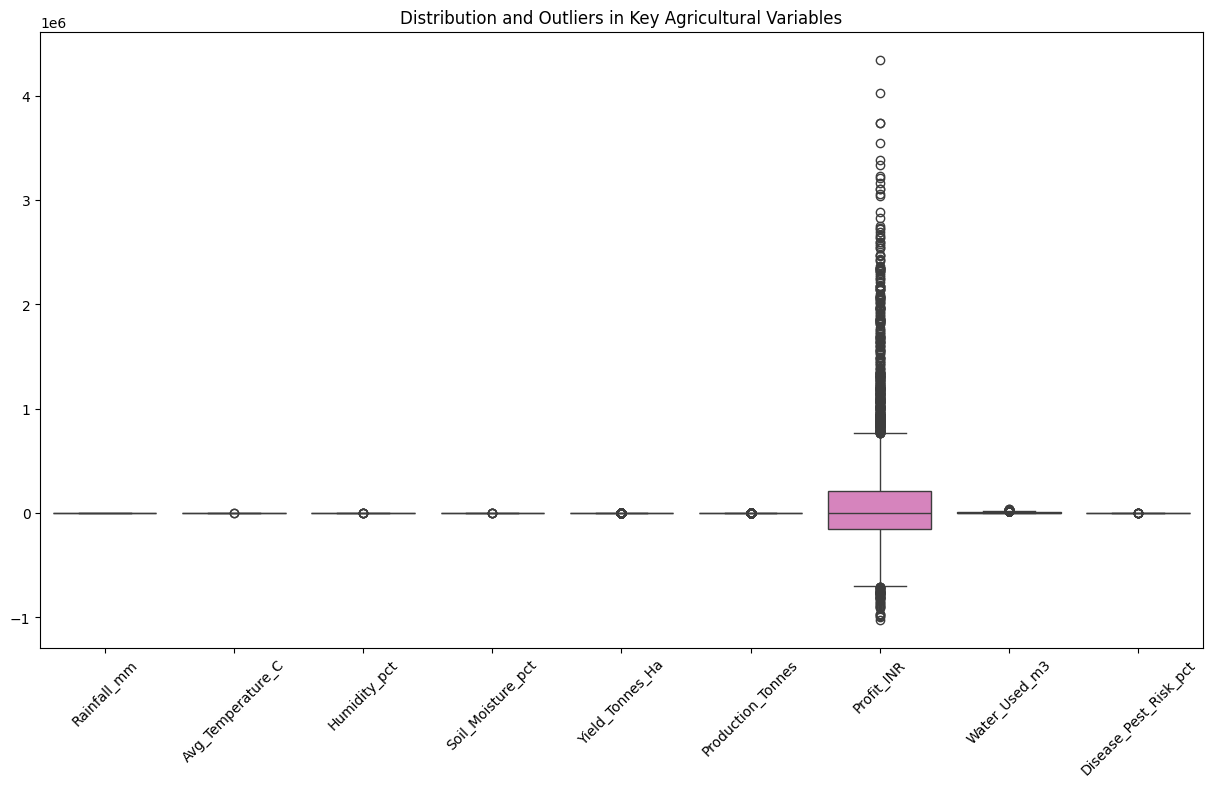

In [28]:
numerical_columns = [
    'Rainfall_mm',
    'Avg_Temperature_C',
    'Humidity_pct',
    'Soil_Moisture_pct',
    'Yield_Tonnes_Ha',
    'Production_Tonnes',
    'Profit_INR',
    'Water_Used_m3',
    'Disease_Pest_Risk_pct'
]

plt.figure(figsize=(15,8))

sns.boxplot(data=df[numerical_columns])

plt.xticks(rotation=45)
plt.title('Distribution and Outliers in Key Agricultural Variables')

plt.show()

Avg Yield By Season

In [29]:
season_yield = df.groupby('Season')['Yield_Tonnes_Ha'].mean().sort_values(
    ascending=False
)

season_yield

,Yield_Tonnes_Ha
Season,
Kharif,5.628612
Rabi,5.039435
Zaid,4.641313


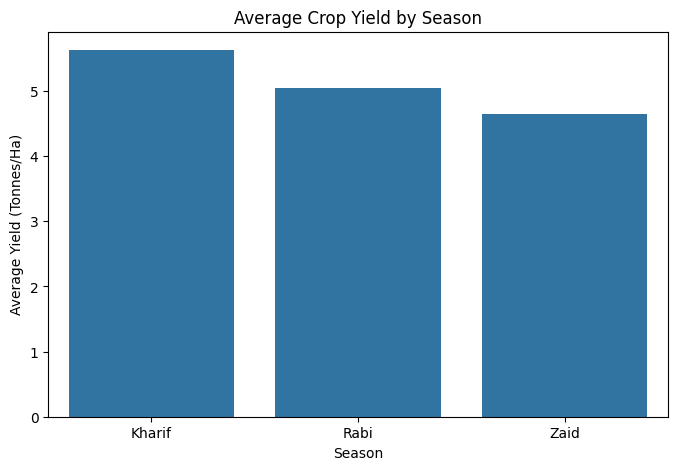

In [30]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=season_yield.index,
    y=season_yield.values
)

plt.title('Average Crop Yield by Season')
plt.xlabel('Season')
plt.ylabel('Average Yield (Tonnes/Ha)')

plt.show()

Average production

In [31]:
season_production = df.groupby('Season')['Production_Tonnes'].mean()

season_production

,Production_Tonnes
Season,
Kharif,46.311192
Rabi,41.486712
Zaid,38.886111


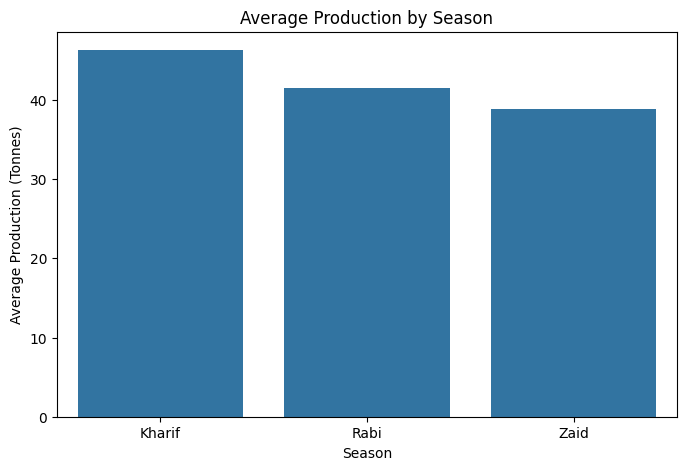

In [32]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=season_production.index,
    y=season_production.values
)

plt.title('Average Production by Season')
plt.xlabel('Season')
plt.ylabel('Average Production (Tonnes)')

plt.show()

Average profit

In [33]:
season_profit = df.groupby('Season')['Profit_INR'].mean().sort_values(
    ascending=False
)

season_profit

,Profit_INR
Season,
Kharif,178914.647555
Rabi,87689.470191
Zaid,-24804.824916


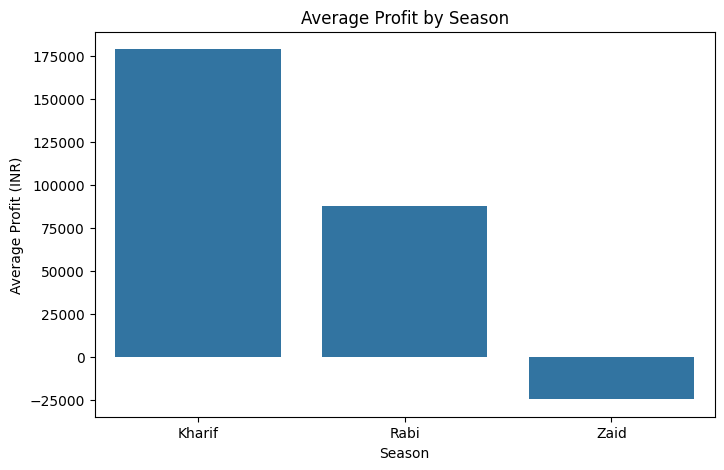

In [34]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=season_profit.index,
    y=season_profit.values
)

plt.title('Average Profit by Season')
plt.xlabel('Season')
plt.ylabel('Average Profit (INR)')

plt.show()

Rainfall by season

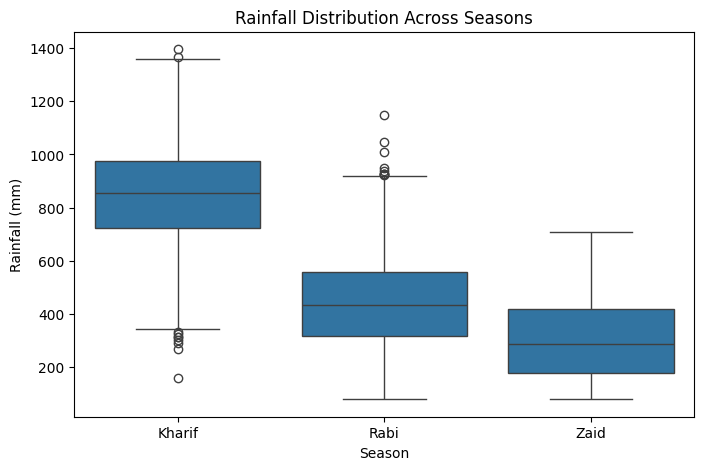

In [35]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='Season',
    y='Rainfall_mm'
)

plt.title('Rainfall Distribution Across Seasons')
plt.xlabel('Season')
plt.ylabel('Rainfall (mm)')

plt.show()

Temperature by season

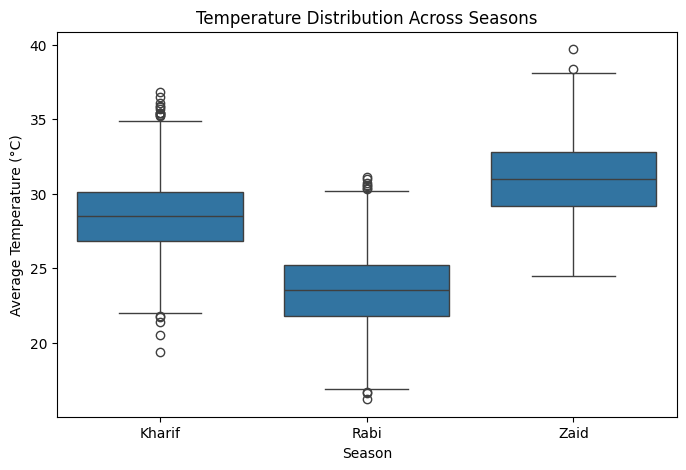

In [36]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='Season',
    y='Avg_Temperature_C'
)

plt.title('Temperature Distribution Across Seasons')
plt.xlabel('Season')
plt.ylabel('Average Temperature (°C)')

plt.show()

Soil moisture by season

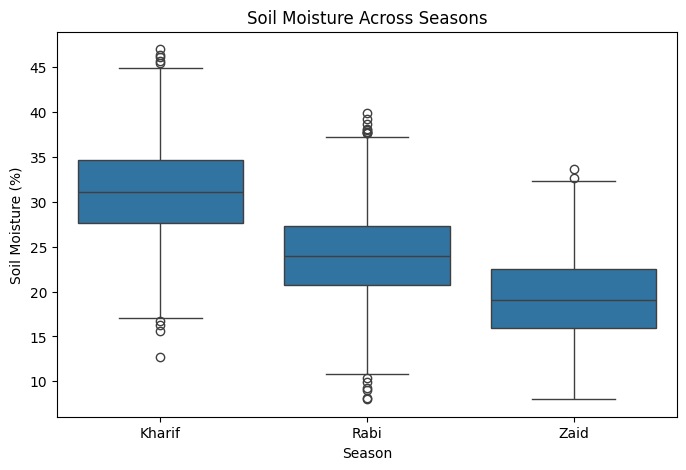

In [37]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='Season',
    y='Soil_Moisture_pct'
)

plt.title('Soil Moisture Across Seasons')
plt.xlabel('Season')
plt.ylabel('Soil Moisture (%)')

plt.show()

Number of farms per crop

In [39]:
df["Crop"].value_counts()

,count
Crop,
Rice,690
Wheat,614
Maize,551
Cotton,508
Pulses,496
Groundnut,424
Chilli,412
Sugarcane,305


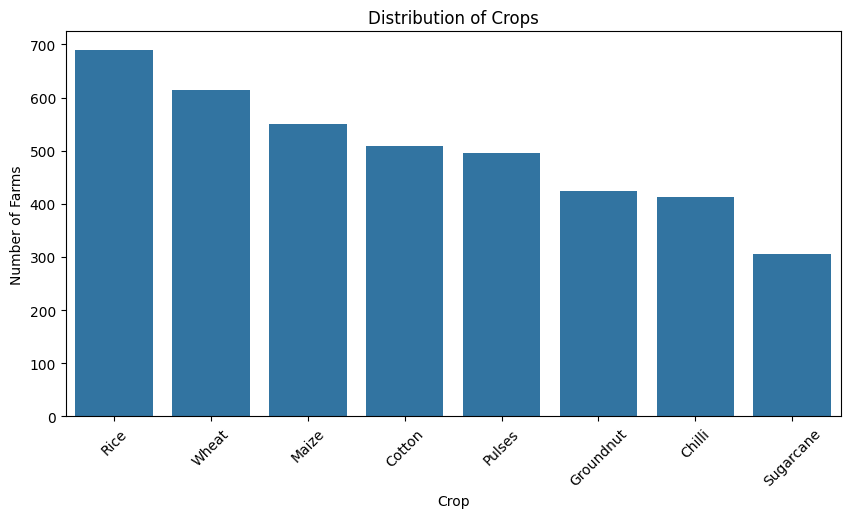

In [40]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x='Crop',
    order=df['Crop'].value_counts().index
)

plt.title('Distribution of Crops')
plt.xlabel('Crop')
plt.ylabel('Number of Farms')

plt.xticks(rotation=45)

plt.show()

Average yield by crop

In [41]:
crop_yield = df.groupby('Crop')['Yield_Tonnes_Ha'].mean().sort_values(
    ascending=False
)

crop_yield

,Yield_Tonnes_Ha
Crop,
Sugarcane,46.642361
Maize,2.710036
Rice,2.431304
Wheat,2.108013
Chilli,1.542767
Groundnut,1.322901
Cotton,1.229783
Pulses,0.921512


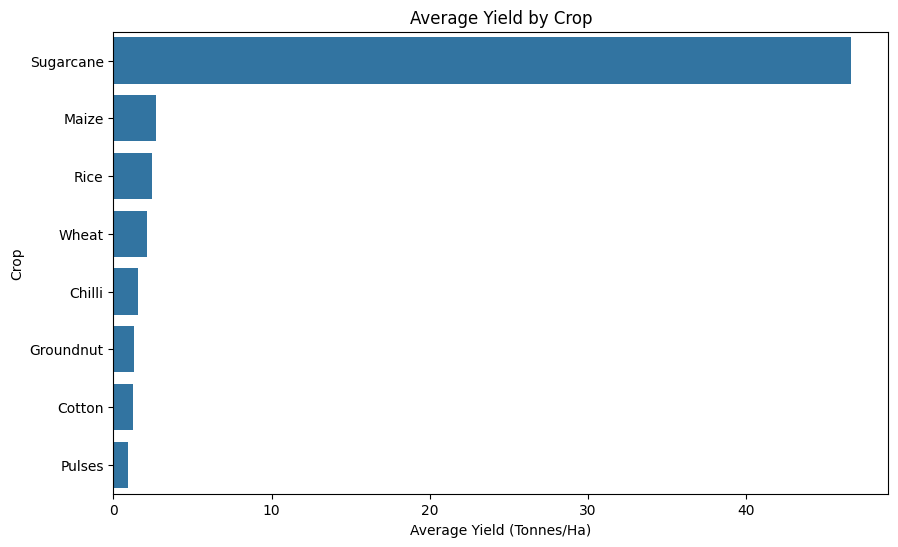

In [42]:
plt.figure(figsize=(10,6))

sns.barplot(
    x=crop_yield.values,
    y=crop_yield.index
)

plt.title('Average Yield by Crop')
plt.xlabel('Average Yield (Tonnes/Ha)')
plt.ylabel('Crop')

plt.show()

Average Crop Yield Across Seasons

In [43]:
crop_season_yield = df.pivot_table(
    values='Yield_Tonnes_Ha',
    index='Crop',
    columns='Season',
    aggfunc='mean'
)

crop_season_yield

Season,Kharif,Rabi,Zaid
Crop,,,
Chilli,1.731459,1.465031,1.195312
Cotton,1.374512,1.198358,0.960217
Groundnut,1.484974,1.233164,1.037778
Maize,2.966410,2.603648,2.290952
Pulses,1.036063,0.875962,0.669677
Rice,2.698376,2.322847,1.900490
Sugarcane,53.459120,43.286124,38.423922
Wheat,2.253664,2.057468,1.748588


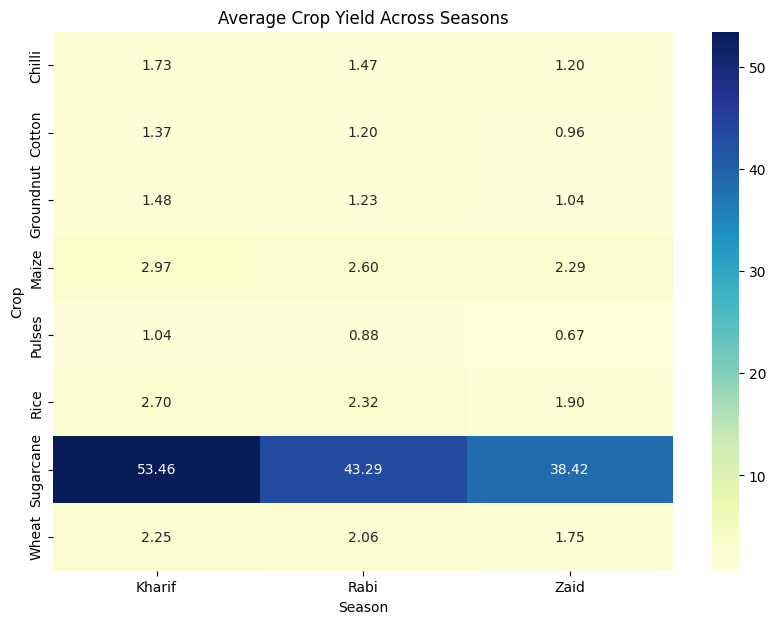

In [44]:
plt.figure(figsize=(10,7))

sns.heatmap(
    crop_season_yield,
    annot=True,
    fmt='.2f',
    cmap='YlGnBu'
)

plt.title('Average Crop Yield Across Seasons')
plt.xlabel('Season')
plt.ylabel('Crop')

plt.show()

Average Yield by irrigation method

In [45]:
df['Irrigation_Method'].value_counts()

,count
Irrigation_Method,
Flood,1310
Rainfed,1041
Drip,915
Sprinkler,734


In [46]:
irrigation_yield = df.groupby(
    'Irrigation_Method'
)['Yield_Tonnes_Ha'].mean().sort_values(ascending=False)

irrigation_yield

,Yield_Tonnes_Ha
Irrigation_Method,
Drip,6.577989
Sprinkler,5.160627
Flood,4.863977
Rainfed,4.602142


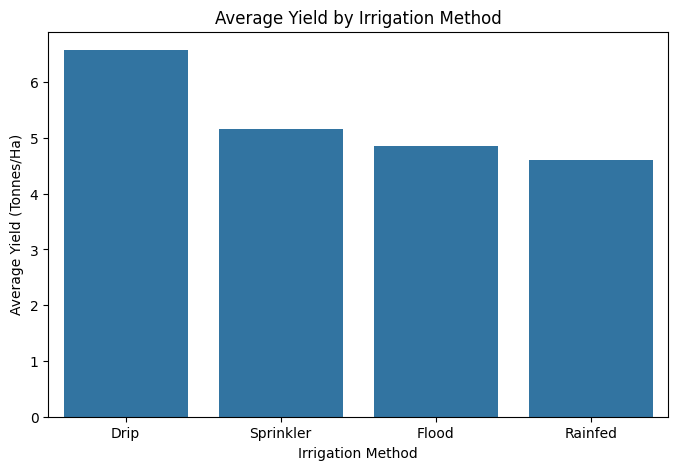

In [47]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=irrigation_yield.index,
    y=irrigation_yield.values
)

plt.title('Average Yield by Irrigation Method')
plt.xlabel('Irrigation Method')
plt.ylabel('Average Yield (Tonnes/Ha)')

plt.show()

Water Efficiency across seasons

In [48]:
water_efficiency = df.groupby(
    'Season'
)['Water_Efficiency_t_per_1000m3'].mean()

water_efficiency

,Water_Efficiency_t_per_1000m3
Season,
Kharif,5.891834
Rabi,5.186122
Zaid,4.413239


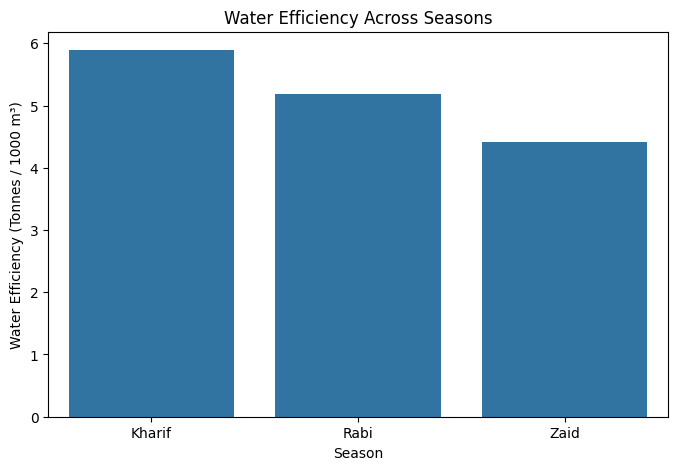

In [49]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=water_efficiency.index,
    y=water_efficiency.values
)

plt.title('Water Efficiency Across Seasons')
plt.xlabel('Season')
plt.ylabel('Water Efficiency (Tonnes / 1000 m³)')

plt.show()

Resource usage

In [50]:
resource_columns = [
    'Nitrogen_kg_ha',
    'Phosphorus_kg_ha',
    'Potassium_kg_ha',
    'Fertilizer_kg_ha',
    'Pesticide_Litre_ha',
    'Water_Used_m3'
]

season_resources = df.groupby('Season')[resource_columns].mean()

season_resources

,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Fertilizer_kg_ha,Pesticide_Litre_ha,Water_Used_m3
Season,,,,,,
Kharif,120.020124,58.096515,105.303485,187.077965,5.079747,6102.201237
Rabi,120.402827,57.311002,103.926060,185.407068,5.024690,5846.987093
Zaid,120.525421,58.129125,105.416835,184.638047,5.171212,6419.893939


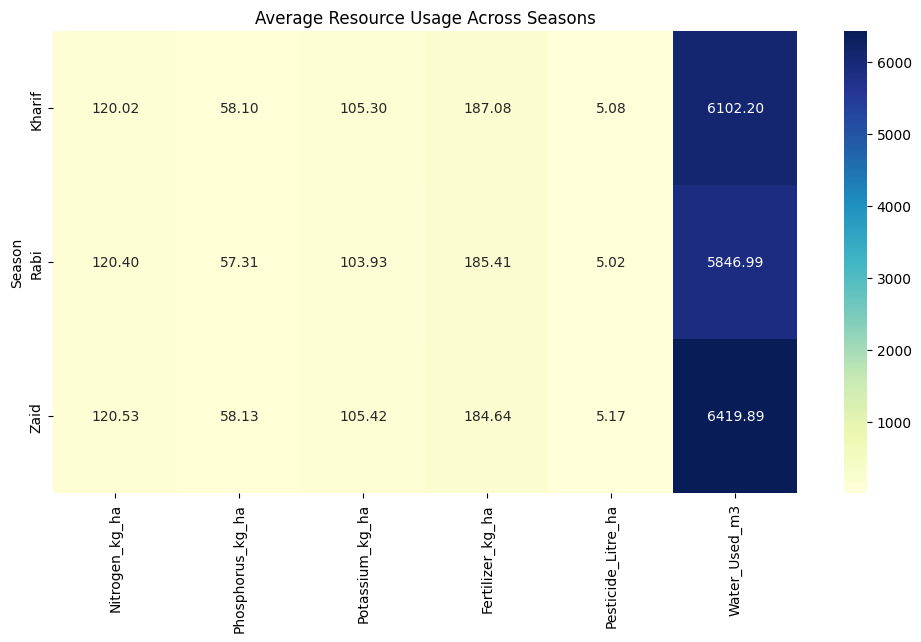

In [51]:
plt.figure(figsize=(12,6))

sns.heatmap(
    season_resources,
    annot=True,
    fmt='.2f',
    cmap='YlGnBu'
)

plt.title('Average Resource Usage Across Seasons')

plt.show()

Economic Performance

In [52]:
economic_columns = [
    'Market_Price_INR_Tonne',
    'Total_Cost_INR',
    'Revenue_INR',
    'Profit_INR'
]

season_economics = df.groupby('Season')[economic_columns].mean()

season_economics

,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR
Season,,,,
Kharif,44850.906127,531804.408094,710719.055649,178914.647555
Rabi,44747.974800,513836.578365,601526.048556,87689.470191
Zaid,44212.033670,543976.728956,519171.904040,-24804.824916


Revenue Vs Cost

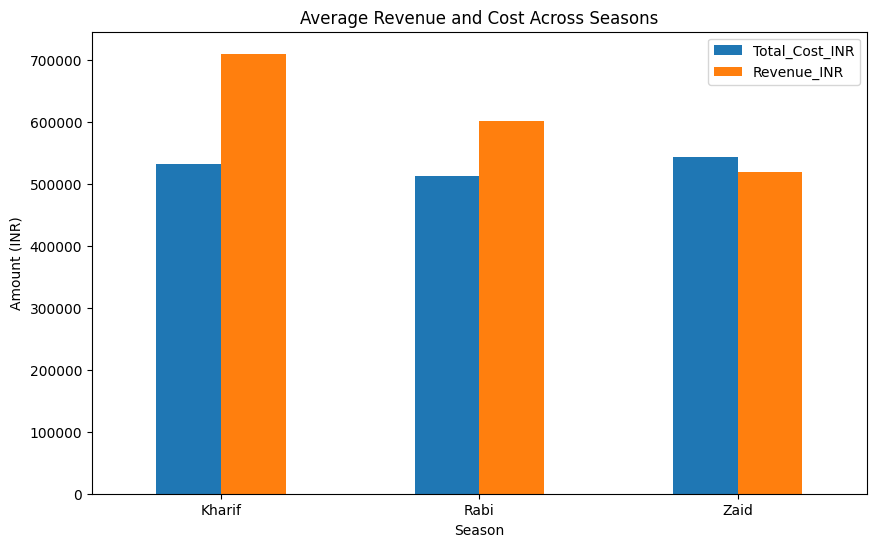

In [53]:
economic_plot = df.groupby('Season')[
    ['Total_Cost_INR', 'Revenue_INR']
].mean()

economic_plot.plot(
    kind='bar',
    figsize=(10,6)
)

plt.title('Average Revenue and Cost Across Seasons')
plt.xlabel('Season')
plt.ylabel('Amount (INR)')
plt.xticks(rotation=0)

plt.show()

Which numerical factors are associated with agricultural performance?

In [54]:
numerical_df = df.select_dtypes(include=np.number)

correlation_matrix = numerical_df.corr()

correlation_matrix

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
Farm_Area_Hectares,1.000000,0.007256,0.036870,0.000471,0.001821,0.009857,0.004033,0.013658,-0.006625,0.000195,0.014975,-0.005207,0.015236,0.030203,0.197842,-0.021571,0.962211,0.543364,0.115241,0.576015,0.028930,0.025963
Rainfall_mm,0.007256,1.000000,0.198492,0.521069,-0.362779,0.016657,0.508941,0.007460,0.020940,0.031373,0.024602,0.004058,-0.018581,0.030951,0.024447,0.000639,0.013041,0.098146,0.107648,0.002240,0.058102,0.621762
Avg_Temperature_C,0.036870,0.198492,1.000000,0.138136,-0.033863,0.029988,0.084001,0.018707,0.008508,0.022993,0.015861,0.006657,-0.031943,0.009996,0.007346,0.002951,0.041030,0.026703,0.009043,0.022995,0.006534,0.245613
Humidity_pct,0.000471,0.521069,0.138136,1.000000,-0.297298,0.028447,0.446470,0.001198,-0.005963,-0.003070,0.024623,-0.004028,-0.045598,0.012297,0.003614,0.000262,0.006023,0.057358,0.063775,-0.002086,0.026169,0.545093
Sunlight_Hours_Day,0.001821,-0.362779,-0.033863,-0.297298,1.000000,-0.017806,-0.302846,0.009920,0.001544,-0.014407,-0.013073,-0.017238,0.021257,-0.015341,-0.023504,-0.000696,-0.000655,-0.047216,-0.054822,-0.005717,-0.021386,-0.253251
Soil_pH,0.009857,0.016657,0.029988,0.028447,-0.017806,1.000000,0.031183,0.006286,0.016620,-0.019407,-0.010591,-0.010135,-0.004181,-0.020672,-0.012512,0.022226,0.005302,-0.008798,-0.013145,-0.022859,-0.010087,0.031141
Soil_Moisture_pct,0.004033,0.508941,0.084001,0.446470,-0.302846,0.031183,1.000000,0.008884,0.013406,0.007796,0.008782,-0.023159,-0.019556,0.010999,0.004787,0.016914,0.002741,0.079380,0.091281,0.003183,0.027776,0.375547
Nitrogen_kg_ha,0.013658,0.007460,0.018707,0.001198,0.009920,0.006286,0.008884,1.000000,0.010199,0.010490,-0.032440,0.014280,0.014896,0.053149,0.048182,-0.022595,0.011900,0.078252,0.085016,0.022127,0.054896,-0.011503
Phosphorus_kg_ha,-0.006625,0.020940,0.008508,-0.005963,0.001544,0.016620,0.013406,0.010199,1.000000,0.002847,0.012905,-0.029942,-0.007575,0.047941,0.034957,-0.005174,-0.016508,0.034940,0.049747,-0.000752,0.057129,0.032061
Potassium_kg_ha,0.000195,0.031373,0.022993,-0.003070,-0.014407,-0.019407,0.007796,0.010490,0.002847,1.000000,0.017254,-0.004675,0.006862,0.003382,0.004472,0.007572,0.003431,0.028278,0.031192,0.001667,0.006575,0.013403


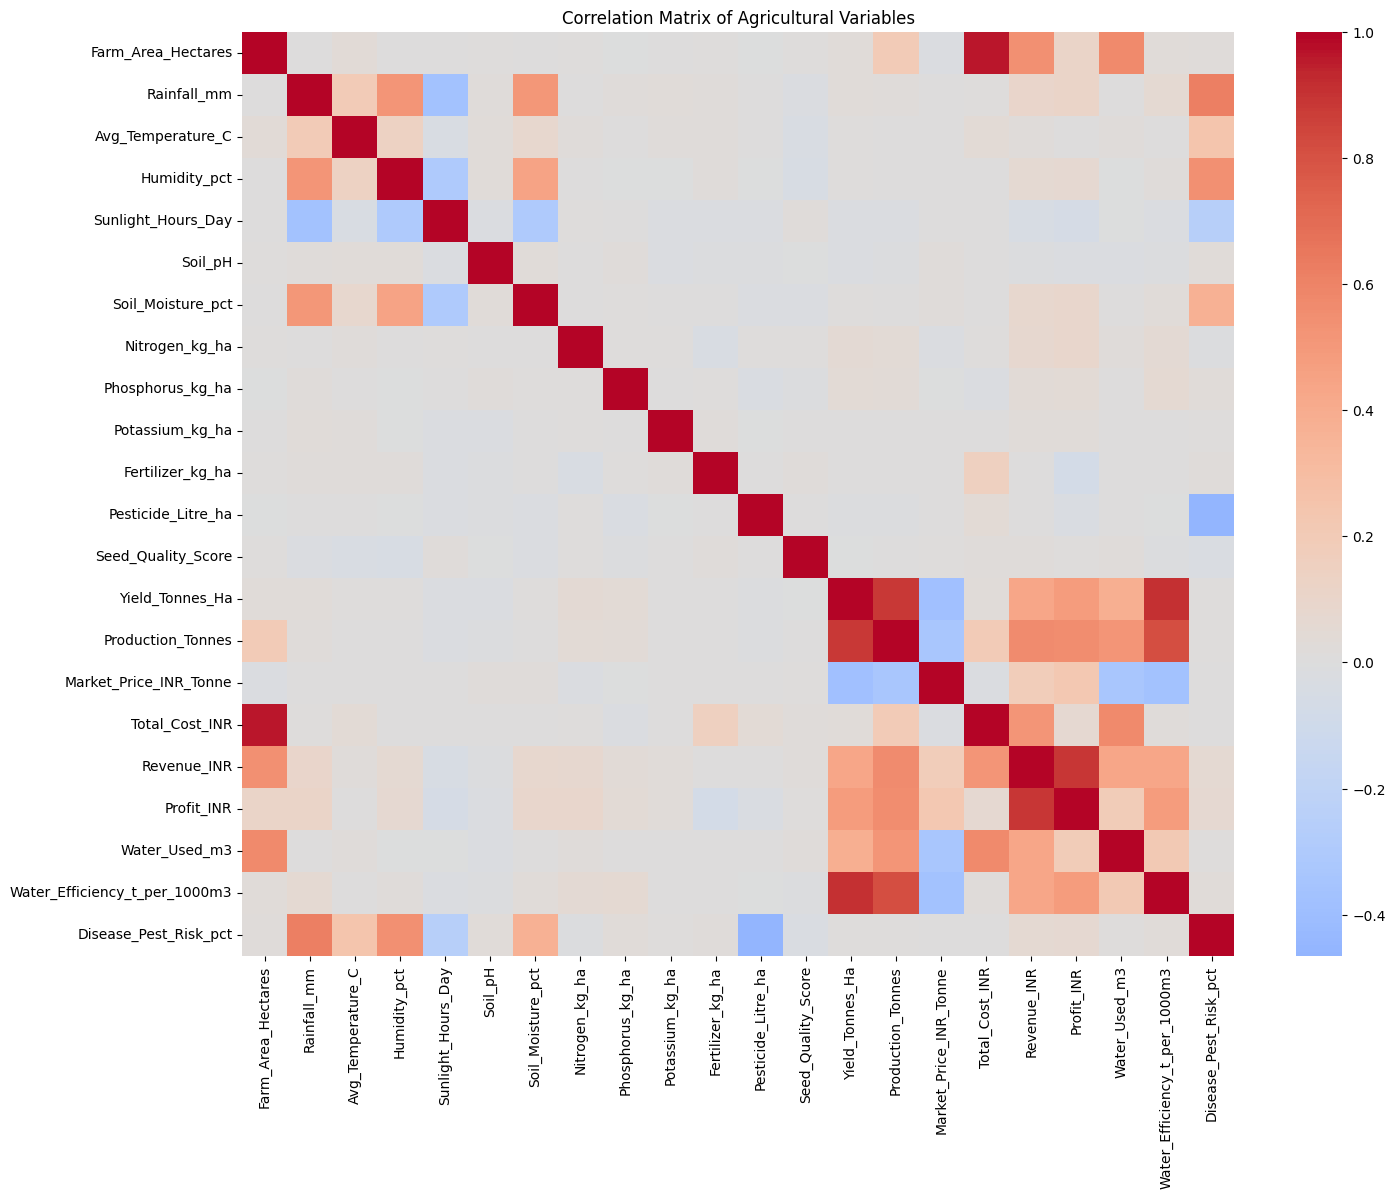

In [55]:
plt.figure(figsize=(16,12))

sns.heatmap(
    correlation_matrix,
    cmap='coolwarm',
    center=0
)

plt.title('Correlation Matrix of Agricultural Variables')

plt.show()

In [56]:
yield_correlation = (
    df.select_dtypes(include=np.number)
    .corr()['Yield_Tonnes_Ha']
    .sort_values(ascending=False)
)

yield_correlation

,Yield_Tonnes_Ha
Yield_Tonnes_Ha,1.000000
Water_Efficiency_t_per_1000m3,0.912568
Production_Tonnes,0.882813
Profit_INR,0.488466
Revenue_INR,0.432152
Water_Used_m3,0.386294
Nitrogen_kg_ha,0.053149
Phosphorus_kg_ha,0.047941
Rainfall_mm,0.030951
Total_Cost_INR,0.030622


Rainfall vs yield

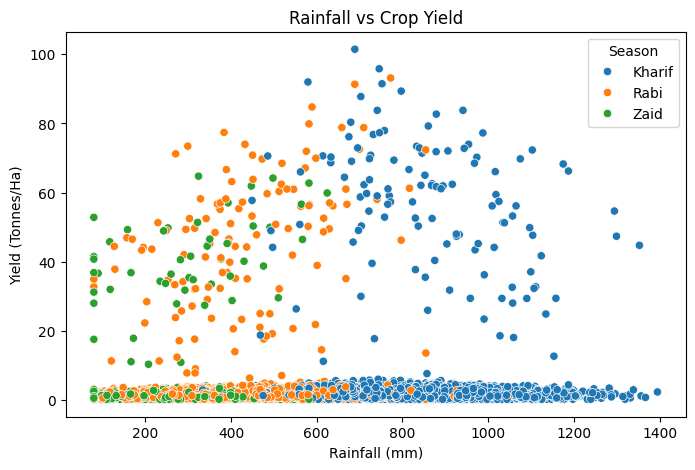

In [57]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='Rainfall_mm',
    y='Yield_Tonnes_Ha',
    hue='Season'
)

plt.title('Rainfall vs Crop Yield')
plt.xlabel('Rainfall (mm)')
plt.ylabel('Yield (Tonnes/Ha)')

plt.show()

Fertilizer vs yield

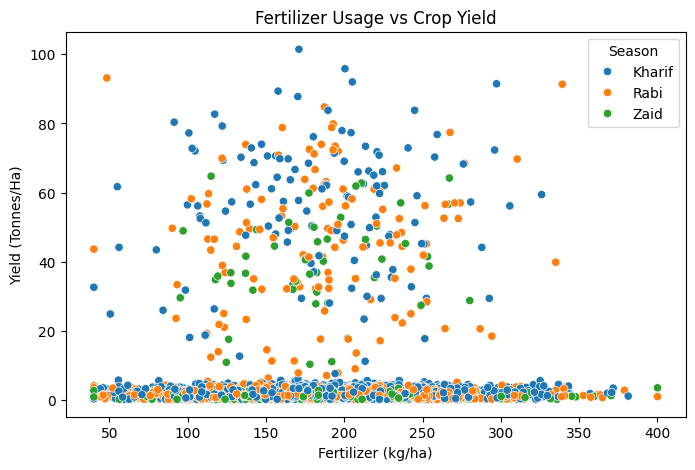

In [58]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='Fertilizer_kg_ha',
    y='Yield_Tonnes_Ha',
    hue='Season'
)

plt.title('Fertilizer Usage vs Crop Yield')
plt.xlabel('Fertilizer (kg/ha)')
plt.ylabel('Yield (Tonnes/Ha)')

plt.show()

Water usage vs yield

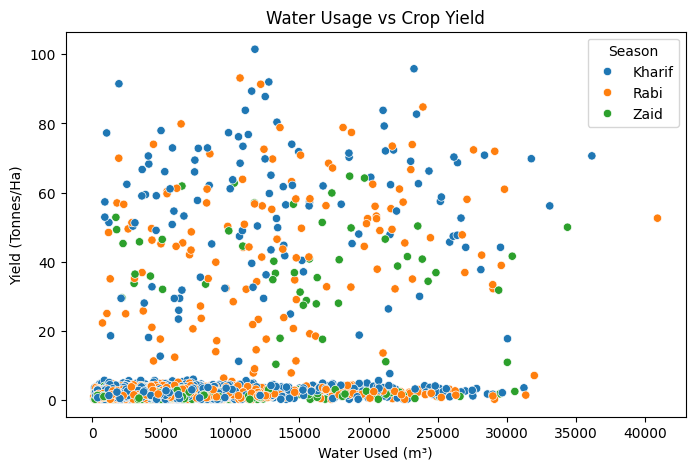

In [59]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='Water_Used_m3',
    y='Yield_Tonnes_Ha',
    hue='Season'
)

plt.title('Water Usage vs Crop Yield')
plt.xlabel('Water Used (m³)')
plt.ylabel('Yield (Tonnes/Ha)')

plt.show()

Disease_Pest_Risk

In [60]:
disease_risk = df.groupby(
    'Season'
)['Disease_Pest_Risk_pct'].mean().sort_values(ascending=False)

disease_risk

,Disease_Pest_Risk_pct
Season,
Kharif,54.467903
Rabi,40.482114
Zaid,38.216667


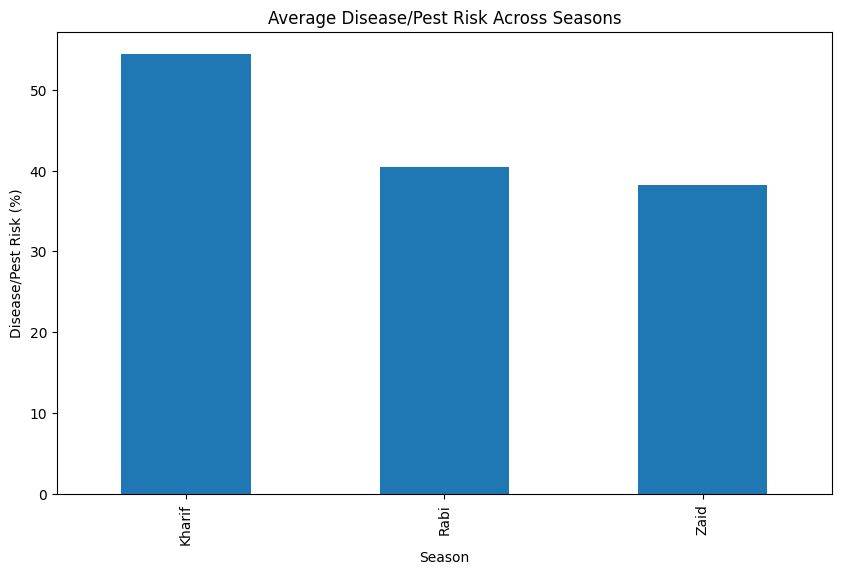

In [61]:
disease_risk.plot(
    kind='bar',
    figsize=(10,6)
)

plt.title('Average Disease/Pest Risk Across Seasons')
plt.xlabel('Season')
plt.ylabel('Disease/Pest Risk (%)')

plt.show()

State Wise Analysis

In [63]:
state_yield = df.groupby(
    'State'
)['Yield_Tonnes_Ha'].mean().sort_values(ascending=False)

state_yield

,Yield_Tonnes_Ha
State,
Punjab,6.121116
Karnataka,5.685481
Gujarat,5.659016
Telangana,5.044477
Maharashtra,5.017480
Madhya Pradesh,4.989940
Tamil Nadu,4.875175
Andhra Pradesh,4.628771


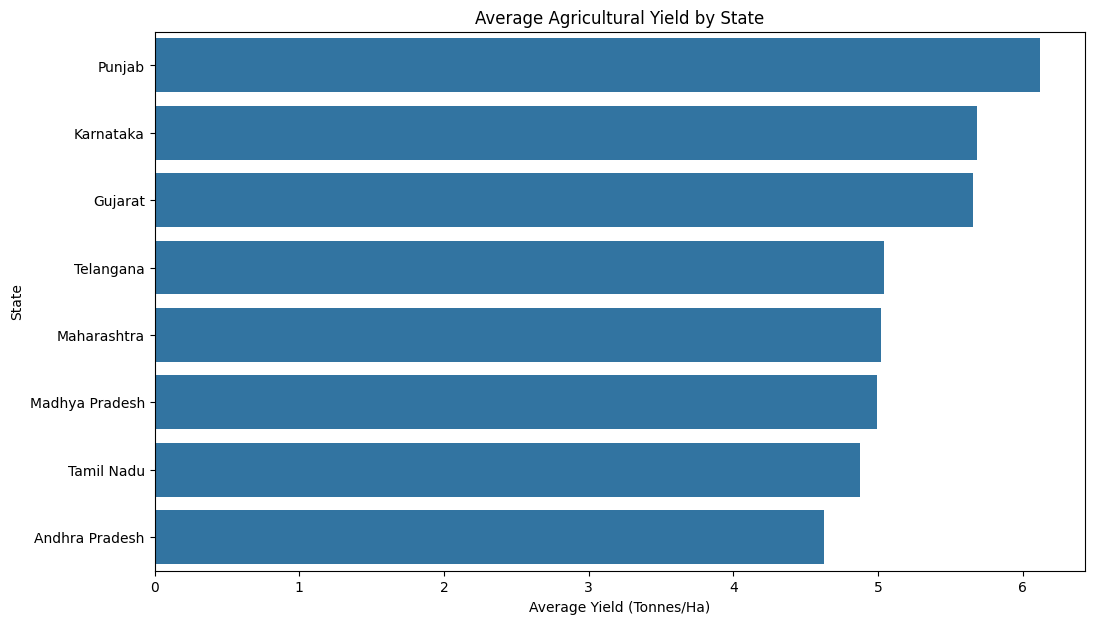

In [64]:
plt.figure(figsize=(12,7))

sns.barplot(
    x=state_yield.values,
    y=state_yield.index
)

plt.title('Average Agricultural Yield by State')
plt.xlabel('Average Yield (Tonnes/Ha)')
plt.ylabel('State')

plt.show()

Season and State

In [65]:
state_season_yield = df.pivot_table(
    values='Yield_Tonnes_Ha',
    index='State',
    columns='Season',
    aggfunc='mean'
)

state_season_yield

Season,Kharif,Rabi,Zaid
State,,,
Andhra Pradesh,5.676958,3.470931,4.448000
Gujarat,6.338416,5.441700,4.066716
Karnataka,6.455024,4.567864,6.623243
Madhya Pradesh,5.985265,3.760385,5.478889
Maharashtra,5.430315,5.501927,2.277778
Punjab,4.100633,8.609355,5.909610
Tamil Nadu,5.520534,4.501394,4.097746
Telangana,5.552436,4.784569,4.248471


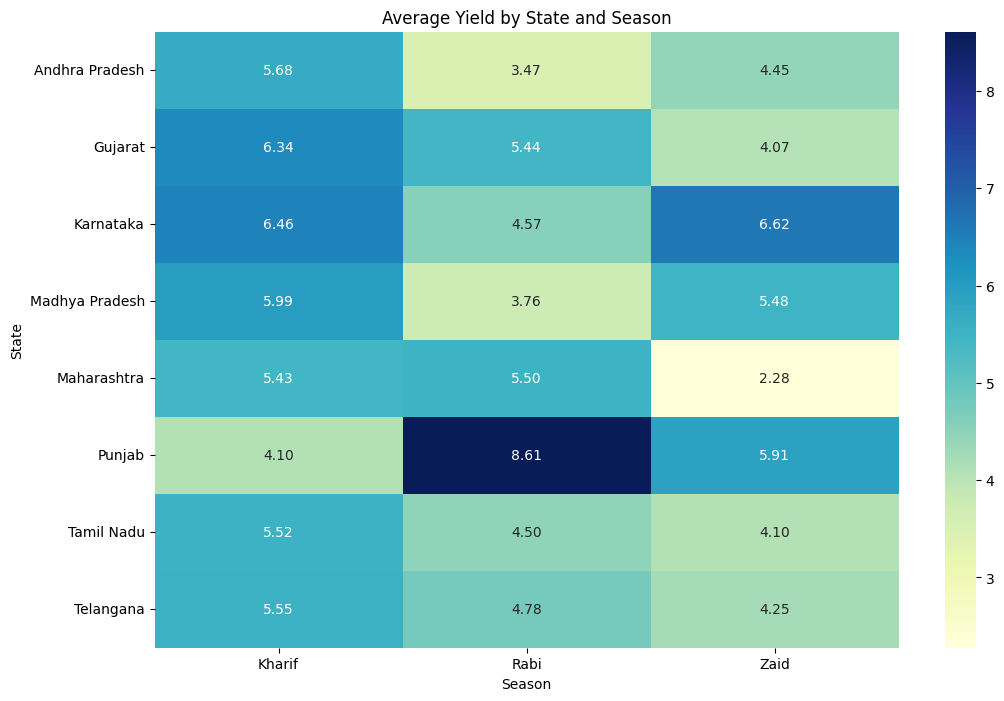

In [66]:
plt.figure(figsize=(12,8))

sns.heatmap(
    state_season_yield,
    annot=True,
    fmt='.2f',
    cmap='YlGnBu'
)

plt.title('Average Yield by State and Season')

plt.show()

Statistical test

In [67]:
seasons = df['Season'].dropna().unique()

season_groups = [
    df[df['Season'] == season]['Yield_Tonnes_Ha']
    for season in seasons
]

anova_result = stats.f_oneway(*season_groups)

anova_result

F_onewayResult(statistic=np.float64(1.5438804542488311), pvalue=np.float64(0.21367813841792296))

In [68]:
print("F-statistic:", anova_result.statistic)
print("P-value:", anova_result.pvalue)

F-statistic: 1.5438804542488311
P-value: 0.21367813841792296


In [69]:
final_summary = df.groupby('Season').agg({
    'Yield_Tonnes_Ha': 'mean',
    'Production_Tonnes': 'mean',
    'Profit_INR': 'mean',
    'Water_Used_m3': 'mean',
    'Water_Efficiency_t_per_1000m3': 'mean',
    'Disease_Pest_Risk_pct': 'mean'
}).round(2)

final_summary

,Yield_Tonnes_Ha,Production_Tonnes,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
Season,,,,,,
Kharif,5.63,46.31,178914.65,6102.20,5.89,54.47
Rabi,5.04,41.49,87689.47,5846.99,5.19,40.48
Zaid,4.64,38.89,-24804.82,6419.89,4.41,38.22


CREATED BY SIMMY KUMARI